---
title: "Heatmaps"
subtitle: "DS 2023 | Communicating with Data"
---

:::{image}images/heatmap.png
:width: 500px
:align: left
:alt: A grid of colored cells encoding a matrix of values, with a colorbar legend
:::

## Overview

A **heatmap** displays a whole matrix of numbers at once by drawing it as a grid of colored cells.

Each cell sits at the intersection of a **row** and a **column**, and its **color** encodes a single numeric **value**. Nothing is plotted with position on a value axis &mdash; instead, the value becomes *color*.

That makes a heatmap a table you can *see*. Where a spreadsheet asks you to read hundreds of numbers one at a time, a heatmap lets your eye sweep across the grid and pick out the bright cells, the dark cells, the rows and columns that stand out.

The three ingredients of every heatmap:

- The **rows** &mdash; one categorical or positional axis (e.g. documents, genes, months). Their order is a design choice.
- The **columns** &mdash; a second categorical or positional axis (e.g. topics, samples, years). Their order is also a design choice.
- The **value in each cell**, mapped to **color** through a *colormap*. Color is the third dimension: it carries the actual measurement.

The essential idea: **a heatmap turns a matrix into an image.** Each number becomes one pixel-like tile, and the colormap is the dictionary that translates value into hue and brightness. The whole design problem of a heatmap is choosing that dictionary well.

## Use Cases

You reach for a heatmap whenever your data is naturally a **matrix** &mdash; a rectangle of one number for every (row, column) pair.

They are especially good at:

- **Seeing structure in a large table at a glance.** Block patterns, bright stripes, and dark gaps jump out that you would never notice scanning raw numbers.
- **Correlation and confusion matrices.** A square matrix of relationships between variables (or predicted-vs-actual class counts) is almost always shown as a heatmap.
- **"Wide" data across two categories** &mdash; sales by product and region, temperature by station and month, expression by gene and sample.
- **Document&ndash;feature matrices in text analysis** &mdash; how much each document draws on each theme, which is exactly the data we use below.

Because a heatmap only asks for a matrix of numbers, it appears everywhere: biology, finance, machine learning, digital humanities. Its natural companion is the **dendrogram**: reorder the rows and columns of a heatmap so that similar ones sit together and the blocks of color become obvious. That combination is a *clustered heatmap*, and we build one at the end.

## How the color mapping works

A heatmap is a picture of one small computation, repeated for every cell: **take a number, turn it into a color.** That happens in two steps &mdash; *normalize*, then *look up*.

**1. Normalize the value to the unit interval.** A colormap is defined on $[0, 1]$, but your data lives on some other range. So we first rescale. With a lower bound $v_{\min}$ and an upper bound $v_{\max}$, a value $v$ becomes

$$t = \frac{v - v_{\min}}{v_{\max} - v_{\min}}, \qquad t \in [0, 1].$$

By default $v_{\min}$ and $v_{\max}$ are the smallest and largest values in the matrix, so the full color range is used. Setting them yourself (`vmin`, `vmax`) fixes the scale &mdash; essential when you want two heatmaps to be directly comparable.

**2. Look the normalized value up in a colormap.** A **colormap** is just a function $C : [0, 1] \to \text{color}$. Feed it $t$ and it returns the cell's color:

$$\text{color} = C(t).$$

At $t = 0$ you get one end of the colormap, at $t = 1$ the other, and everything in between is interpolated.

There are two families of colormap, and choosing the right one matters:

1. **Sequential** (`viridis`, `Blues`, `rocket`) &mdash; brightness runs smoothly from low to high. Use these for quantities that go from *little* to *lots*: counts, proportions, magnitudes. Our topic proportions are sequential data.
2. **Diverging** (`coolwarm`, `vlag`, `RdBu`) &mdash; two hues meet at a neutral midpoint. Use these when values have a **meaningful center** (like $0$ for a correlation, or a baseline you deviate from). Set that midpoint with `center=0` so the neutral color lands exactly there.

:::{note}
Normalization does not have to be linear. When most values are tiny and a few are large &mdash; exactly the case for our topic matrix &mdash; a linear scale paints almost everything the same color. A **logarithmic** normalization, $t \propto \log v$, spreads the small values apart so hidden structure becomes visible. We use one below.
:::

:::{caution}
Color is a persuasive channel, so a heatmap can mislead. The wrong `vmin`/`vmax` can hide real variation or manufacture false contrast, and a *rainbow* colormap (like `jet`) creates edges where the data is smooth. Prefer perceptually uniform maps such as `viridis`, and be honest about your normalization.
:::

## Creating a heatmap from scratch

At its core a heatmap is just an **array drawn as an image**. Matplotlib's `plt.imshow()` does exactly that: hand it a 2-D array and it colors each entry. Let's build one by hand so the mechanism &mdash; array in, color grid out &mdash; is completely transparent.

We start with the standard imports.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The dataset: an Austen&ndash;Melville topic matrix

Our data comes from a **topic model** fit to a corpus that mixes the novels of **Jane Austen** and **Herman Melville**. A topic model breaks a collection of texts into a fixed number of latent "topics" &mdash; recurring blends of vocabulary &mdash; and then describes every document as a *mixture* of those topics.

The file `austen-melville-LDA_THETA-40.csv` is the model's **THETA matrix**. It has one row per **chapter** and one column per **topic**:

- `book_id` &mdash; a Project Gutenberg identifier for the book the chapter comes from.
- `chap_id` &mdash; the chapter number within that book.
- `T00`&ndash;`T39` &mdash; forty topic columns. Each value is the **probability** that a randomly chosen word in that chapter belongs to that topic. Because they are a probability distribution, the forty values in each row **sum to $1$**.

Let's load it and look at the shape.

In [2]:
theta = pd.read_csv('austen-melville-LDA_THETA-40.csv')
print(theta.shape)
theta.head()

(1173, 42)


,book_id,chap_id,T00,T01,T02,T03,T04,T05,T06,T07,...,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39
0,105,1,0.000065,0.000065,0.000065,0.000065,0.000065,0.246958,0.000065,0.000065,...,0.000065,0.000065,0.000065,0.000065,0.000065,0.612002,0.000065,0.000065,0.000065,0.000065
1,105,2,0.000089,0.000089,0.000089,0.000089,0.000089,0.694386,0.000089,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.218228,0.000089,0.000089,0.000089,0.000089
2,105,3,0.000060,0.000060,0.000060,0.000060,0.000060,0.115819,0.000060,0.000060,...,0.000060,0.000060,0.000060,0.000060,0.000060,0.486383,0.000060,0.000060,0.040438,0.000060
3,105,4,0.000089,0.000089,0.000089,0.000089,0.034618,0.769699,0.000089,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.170896,0.000089,0.000089,0.000089,0.000089
4,105,5,0.000059,0.000059,0.000059,0.000059,0.000059,0.197815,0.000059,0.000059,...,0.000059,0.000059,0.000059,0.000059,0.000059,0.616535,0.000059,0.000059,0.000059,0.000059


There are $1{,}173$ chapters and $40$ topic columns. Let's pull out just the topic columns and confirm two things about the numbers: the rows really do sum to $1$, and the individual values are **tiny and lopsided** &mdash; most are near zero, a few are large.

In [3]:
topic_cols = [c for c in theta.columns if c.startswith('T')]

print("number of topics:", len(topic_cols))
print("row sums (should be ~1):", theta[topic_cols].sum(axis=1).head(3).round(4).to_list())
print("min value:", theta[topic_cols].values.min())
print("max value:", theta[topic_cols].values.max())

number of topics: 40
row sums (should be ~1): [1.0, 1.0, 1.0]
min value: 2.073140393069526e-06
max value: 0.9986895161290316


A full $1{,}173 \times 40$ heatmap would be a tall, unreadable smear. To *understand* the mechanism, we take a small, legible slice: the first ten chapters and the first ten topics. That gives us a $10 \times 10$ matrix we can actually inspect cell by cell.

In [4]:
slice_df = theta.loc[:9, topic_cols[:10]]
M = slice_df.to_numpy()
M.shape

(10, 10)

Now the heart of it. `plt.imshow()` takes that array and draws each entry as a colored tile; `plt.colorbar()` adds the legend that maps color back to value. We pass a **sequential** colormap (`viridis`) because topic proportions run from little to lots.

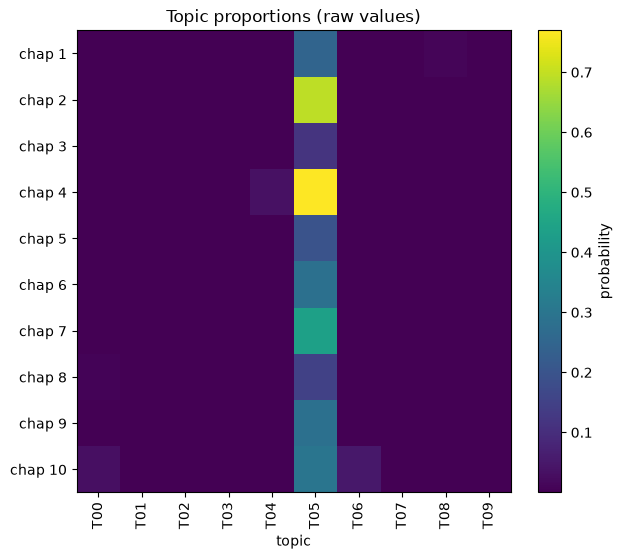

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(M, cmap='viridis', aspect='auto')

ax.set_xticks(range(10), topic_cols[:10], rotation=90)
ax.set_yticks(range(10), [f"chap {i+1}" for i in range(10)])
ax.set_xlabel("topic")
ax.set_title("Topic proportions (raw values)")

fig.colorbar(im, ax=ax, label="probability")
plt.show()

That is a genuine heatmap &mdash; but it is nearly all one color. Because most values are around $0.0001$ and only a couple are large, a **linear** color scale crushes almost every cell to the dark end. The bright cells are real (a topic that dominates a chapter), but the *structure* among the small values is invisible.

This is the normalization problem from the math section. The fix is a **logarithmic** normalization, which spreads the tiny values apart.

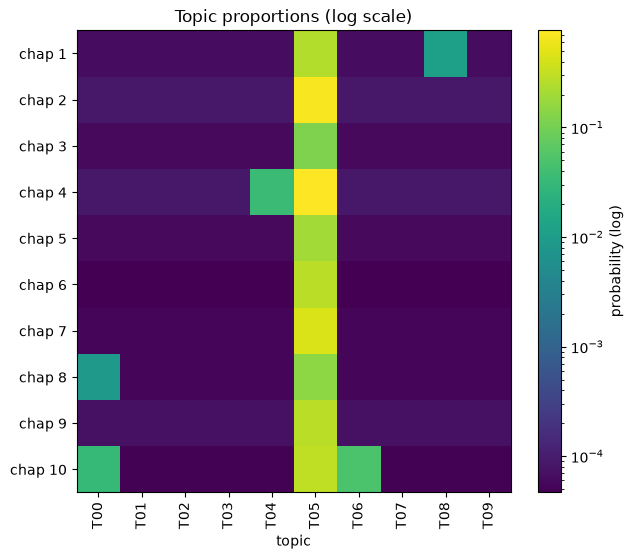

In [6]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(M, cmap='viridis', aspect='auto', norm=LogNorm())

ax.set_xticks(range(10), topic_cols[:10], rotation=90)
ax.set_yticks(range(10), [f"chap {i+1}" for i in range(10)])
ax.set_xlabel("topic")
ax.set_title("Topic proportions (log scale)")

fig.colorbar(im, ax=ax, label="probability (log)")
plt.show()

Same array, same colormap &mdash; but now every cell tells us something. On the log scale you can see which topics a chapter leans on even when the proportions are small. **The array never changed; only the value$\rightarrow$color dictionary did.** That is the whole lesson of normalization.

### A more readable matrix: books &times; topics

Per-chapter rows are noisy and there are far too many of them. A much cleaner view comes from **aggregating**: average each topic's proportion over all the chapters in a book. That collapses $1{,}173$ chapters into $19$ books &mdash; a compact **books &times; topics** matrix that is very readable and, as we'll see, tells a story.

First, a lookup so the rows carry titles and authors instead of bare Gutenberg IDs.

In [7]:
book_info = {
    105:  ("Persuasion",           "Austen"),
    121:  ("Northanger Abbey",     "Austen"),
    141:  ("Mansfield Park",       "Austen"),
    158:  ("Emma",                 "Austen"),
    161:  ("Sense and Sensibility","Austen"),
    946:  ("Lady Susan",           "Austen"),
    1212: ("Love and Friendship",  "Austen"),
    1342: ("Pride and Prejudice",  "Austen"),
    1900: ("Redburn",              "Melville"),
    2701: ("Moby-Dick",            "Melville"),
    4045: ("Omoo",                 "Melville"),
    8118: ("The Piazza Tales",     "Melville"),
    10712:("Israel Potter",        "Melville"),
    13720:("White-Jacket",         "Melville"),
    13721:("Typee",                "Melville"),
    15422:("Bartleby",             "Melville"),
    15859:("Battle-Pieces",        "Melville"),
    21816:("The Confidence-Man",   "Melville"),
    34970:("Mardi",                "Melville"),
}

titles  = {bid: t for bid, (t, a) in book_info.items()}
authors = {bid: a for bid, (t, a) in book_info.items()}

Now average the topic proportions within each book, and label the rows.

In [8]:
book_topics = theta.groupby('book_id')[topic_cols].mean()
book_topics.index = [f"{titles[b]} ({authors[b]})" for b in book_topics.index]
book_topics = book_topics.sort_index()
book_topics.shape

(19, 40)

That is our clean matrix: $19$ books down the side, $40$ topics across the top, each cell the average share of that topic in that book. Now we can hand it to a real library.

## Using Seaborn's heatmap function

Everything we did by hand &mdash; draw the array, add a colorbar, label the axes &mdash; is wrapped up in one call: [`sns.heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html). Give it a DataFrame and it uses the index and columns as tick labels automatically.

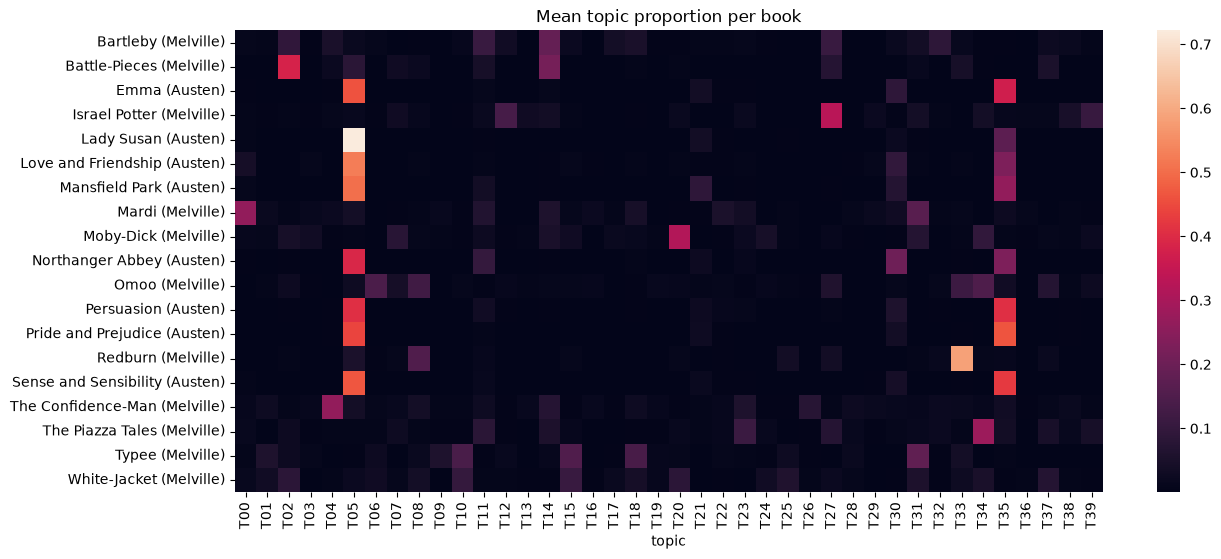

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(book_topics, cmap='rocket', ax=ax)

ax.set_xlabel("topic")
ax.set_ylabel("")
ax.set_title("Mean topic proportion per book")
plt.show()

Even on a linear scale this is far more informative than the chapter slice, because averaging smoothed out the noise. But we can immediately see the same lopsidedness: a handful of very bright topics dominate. Let's fix the scale with `LogNorm` again, and add a thin border between cells so the grid reads cleanly.

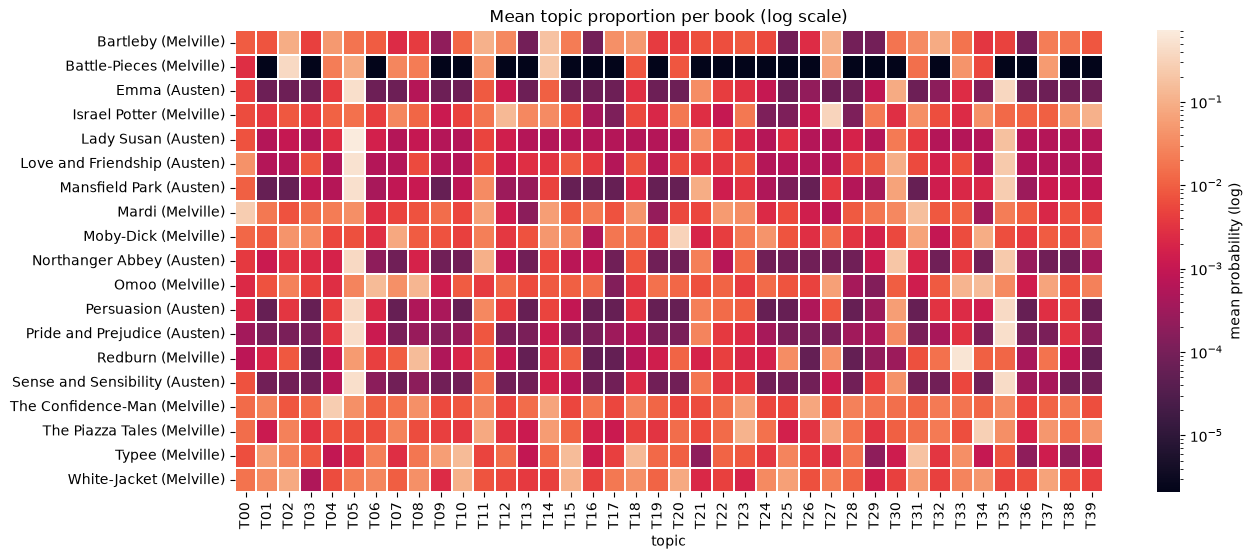

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(book_topics, cmap='rocket', norm=LogNorm(),
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'mean probability (log)'}, ax=ax)

ax.set_xlabel("topic")
ax.set_ylabel("")
ax.set_title("Mean topic proportion per book (log scale)")
plt.show()

Now a structure leaps out. Look at the leftmost books (the Austen novels): almost all of their color piles into a *few* topics on the left, and the rest of the row is dark. The Melville books spread their weight across *many* more topics on the right. Topics that are bright for one author are dark for the other.

That is the payoff of the heatmap: a block pattern that says *Austen and Melville draw on different vocabulary*. Let's make it explicit.

### Annotated values: which topics separate the authors

To read exact numbers off a heatmap, add `annot=True`, which prints each value inside its cell. That is only legible on a **small** matrix, so let's build one: the average topic proportion per **author** (Austen vs. Melville) for a handful of the most distinctive topics.

We'll rank topics by how differently the two authors use them.

In [11]:
author_of_book = theta['book_id'].map(authors)
by_author = theta.groupby(author_of_book.values)[topic_cols].mean()

# rank topics by absolute difference between the two authors
diff = (by_author.loc['Austen'] - by_author.loc['Melville']).abs()
top_topics = diff.sort_values(ascending=False).head(10).index.tolist()

small = by_author[top_topics]
small.round(3)

,T05,T35,T20,T31,T34,T30,T27,T33,T15,T14
Austen,0.491,0.335,0.001,0.001,0.001,0.069,0.001,0.003,0.001,0.004
Melville,0.021,0.017,0.070,0.068,0.064,0.010,0.059,0.048,0.040,0.041


Ten topics, two rows &mdash; small enough to annotate. Because we are comparing two groups against each other, a **diverging** colormap centered at $0$ is not right here (these are all positive proportions); we keep a sequential map but let the annotations carry the exact numbers.

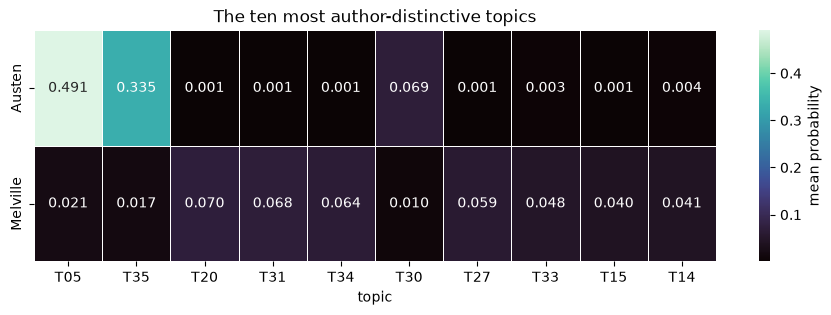

In [12]:
fig, ax = plt.subplots(figsize=(11, 3))

sns.heatmap(small, cmap='mako', annot=True, fmt='.3f',
            linewidths=0.5, cbar_kws={'label': 'mean probability'}, ax=ax)

ax.set_xlabel("topic")
ax.set_ylabel("")
ax.set_title("The ten most author-distinctive topics")
plt.show()

The split is stark. A couple of topics are almost entirely Austen's; the rest belong to Melville. If you looked up their top words in the model's topic table, the Austen topics are full of *feelings, letters, sisters, happiness* while the Melville topics run to *ships, sea, whales, islands* &mdash; the heatmap has recovered the two authors' worlds from raw probabilities.

## Reordering with a clustermap

So far our rows and columns sat in whatever order we handed them. But the order of a heatmap is a free design choice, and the most useful choice is to put **similar rows next to each other** and **similar columns next to each other**. Then the blocks of color line up and the structure becomes unmistakable.

Deciding which rows are "similar" is exactly the job of **hierarchical clustering** &mdash; the same machinery behind the [Dendrograms](Dendrograms.ipynb) notebook. Seaborn's [`sns.clustermap()`](https://seaborn.pydata.org/generated/seaborn.clustermap.html) does it for you: it clusters the rows and the columns, reorders both, and draws a dendrogram along each edge.

We color-code the book labels by author so we can see whether the clustering rediscovers the split on its own.

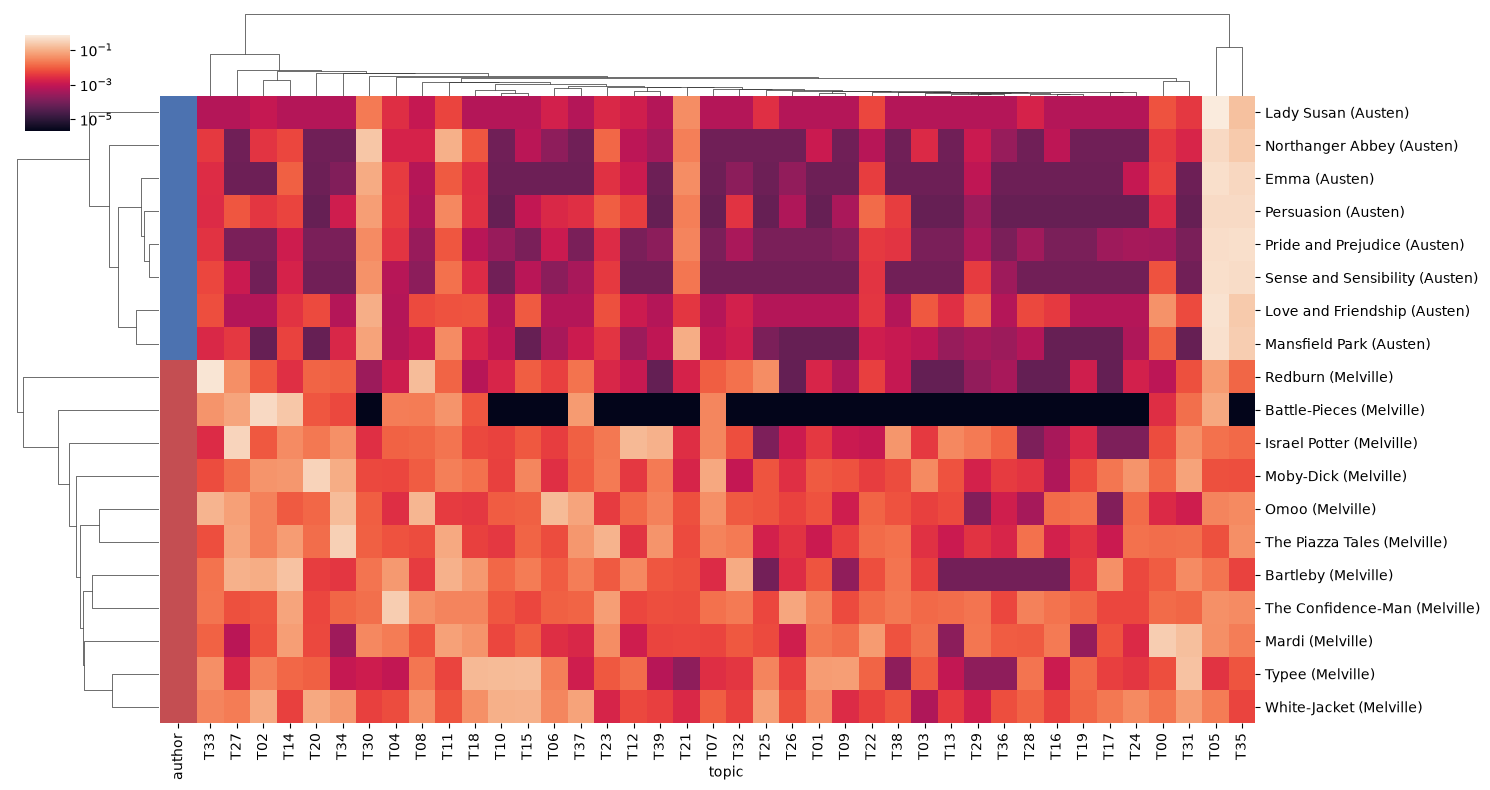

In [13]:
row_colors = pd.Series(
    {label: ('#4C72B0' if 'Austen' in label else '#C44E52')
     for label in book_topics.index},
    name='author')

g = sns.clustermap(
    book_topics,
    cmap='rocket', norm=LogNorm(),
    row_colors=row_colors,
    figsize=(15, 8),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.ax_heatmap.set_xlabel("topic")
g.ax_heatmap.set_ylabel("")
plt.show()

The clustermap sorts the books with no knowledge of who wrote them &mdash; yet the colored bar on the left comes out in two clean runs. **Every Austen novel clusters together; every Melville book clusters together.** The columns are reordered too, so the topics each author favors gather into bright blocks against a dark background.

This is the natural endpoint of the heatmap: the same $19 \times 40$ matrix, but rearranged so the pattern is impossible to miss. Color carried the values; clustering supplied the order; together they turned a wall of probabilities into a picture of two authors.

## Variations and refinements

A few knobs decide whether a heatmap reads well:

- **Colormap.** Match it to the data. Use a **sequential** map (`viridis`, `rocket`, `Blues`) for quantities that run from low to high, like our proportions. Use a **diverging** map with `center=0` (`coolwarm`, `vlag`) only when the data has a meaningful midpoint, such as a correlation matrix. Avoid rainbow maps like `jet`.
- **Normalization.** `vmin` and `vmax` fix the color scale; set them to compare two heatmaps fairly, or to clip distracting outliers. When values span orders of magnitude and cluster near zero &mdash; our exact situation &mdash; reach for `LogNorm` so the small values are not all painted the same color.
- **Aspect and orientation.** A very long, thin matrix is hard to read. **Transpose** it (`book_topics.T`) to swap the axes, or tune `figsize` so the cells are close to square. A readable heatmap usually has cells that are neither slivers nor giant blocks.
- **Aggregate to reduce clutter.** We turned $1{,}173$ noisy chapter rows into $19$ clean book rows by averaging. Summarizing before you plot is often the difference between an unreadable smear and a heatmap that tells a story.

The core design decision, though, is always the same one from the math section: **how you map value to color.** Get the colormap and the normalization right, and the heatmap does the rest.

:::{note}
We averaged chapters up to books to make the matrix legible. What would you *lose* by doing that &mdash; and when might the noisy, full $1{,}173 \times 40$ chapter heatmap reveal something the aggregated view hides?
:::